In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/gaurav/Documents/Classical_ML/grad_result.csv")

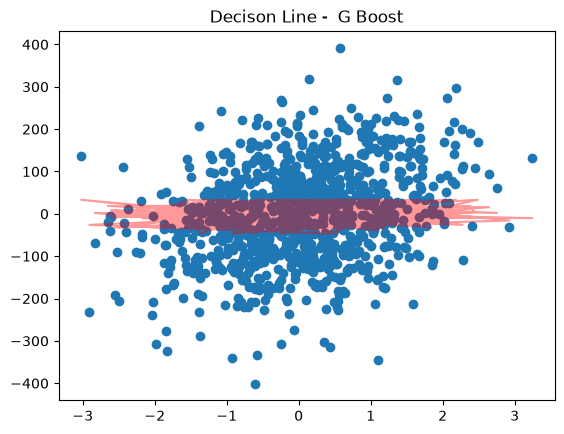

In [3]:
plt.scatter(df.iloc[:, 0], df["target"])
plt.plot(df.iloc[:, 0], df["Prediction_2"], color="red", alpha=0.4)
plt.title("Decison Line -  G Boost")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from rich.progress import (
    Progress,
    BarColumn,
    TextColumn,
    TimeRemainingColumn,
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

X = df.iloc[:, 0].to_numpy()
y = df["target"].to_numpy()

prediction_columns = [col for col in df.columns if col.startswith("Prediction_")]

prediction_columns = sorted(prediction_columns, key=lambda x: int(x.split("_")[1]))

# Keep first 2600 iterations
prediction_columns = prediction_columns[::10]


# ------------------------------------------------------------
# Sort X so the prediction line is drawn correctly
# ------------------------------------------------------------

sort_idx = np.argsort(X)

X_sorted = X[sort_idx]

predictions_sorted = {col: df[col].to_numpy()[sort_idx] for col in prediction_columns}


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    X,
    y,
    alpha=0.35,
    label="Actual Data",
)

(line,) = ax.plot(
    [], [], linewidth=2, label="Gradient Boosting", color="black", alpha=0.6
)

iteration_text = ax.text(
    0.02,
    0.95,
    "",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
)


# ------------------------------------------------------------
# Fixed axis limits
# ------------------------------------------------------------

ax.set_xlim(
    X.min(),
    X.max(),
)

all_predictions = np.concatenate(
    [predictions_sorted[col] for col in prediction_columns]
)

y_min = min(
    y.min(),
    all_predictions.min(),
)

y_max = max(
    y.max(),
    all_predictions.max(),
)

padding = 0.05 * (y_max - y_min)

ax.set_ylim(
    y_min - padding,
    y_max + padding,
)


ax.set_xlabel(df.columns[0])
ax.set_ylabel("Target")

ax.set_title("Gradient Boosting: Decision Line Evolution")

ax.legend()
ax.grid(alpha=0.2)


# ------------------------------------------------------------
# GIF writer
# ------------------------------------------------------------

output_file = "gradient_boosting_2600_iterations.gif"

writer = PillowWriter(fps=5)


# ------------------------------------------------------------
# Save animation with Rich progress bar
# ------------------------------------------------------------

with Progress(
    TextColumn("[progress.description]{task.description}"),
    BarColumn(),
    TextColumn("{task.completed}/{task.total}"),
    TimeRemainingColumn(),
) as progress:
    task = progress.add_task(
        "Rendering GIF",
        total=len(prediction_columns),
    )

    with writer.saving(
        fig,
        output_file,
        dpi=100,
    ):
        for frame, column in enumerate(prediction_columns):
            # ----------------------------------------------
            # Update prediction line
            # ----------------------------------------------

            line.set_data(
                X_sorted,
                predictions_sorted[column],
            )

            # ----------------------------------------------
            # Update iteration number
            # ----------------------------------------------

            iteration = frame + 1

            iteration_text.set_text(f"Boosting Iteration: {iteration}")

            # ----------------------------------------------
            # Render current frame
            # ----------------------------------------------

            writer.grab_frame()

            # ----------------------------------------------
            # Update Rich progress bar
            # ----------------------------------------------

            progress.update(
                task,
                advance=1,
            )


plt.close(fig)

print(f"Animation saved as: {output_file}")


Output()

Animation saved as: gradient_boosting_2600_iterations.gif
